# NexTex AI Take-Home — End-to-End Walkthrough

This notebook demonstrates the full solution: the cloud queue/consumer pipeline (Part 1) and the edge simulator's core components (Part 2), running live against the actual project code — not a re-implementation.

**Two ways to run this notebook:**
1. **Full integration** (recommended): run `docker compose up --build` in the repo root first, then run all cells — they'll hit the real running services on `localhost:8001` / `localhost:8002`.
2. **Component-level only**: skip the "Full Integration" section and just run the "Edge Simulator Components" section, which imports and exercises the Python modules directly with no running services required.

This is the exact sequence of checks performed during development — including one real bug that was found and fixed this way (see Section 3.4).


In [1]:
import sys, os, json, time, base64, asyncio
sys.path.insert(0, "..")
import httpx
print("ready")


ready


## 1. Cloud API — Health Check

Assumes `docker compose up` has been run and `cloud-api` is reachable on port 8001.

In [2]:
CLOUD_API = "http://localhost:8001"

r = httpx.get(f"{CLOUD_API}/health", timeout=5)
print(r.status_code)
print(json.dumps(r.json(), indent=2))


200
{
  "status": "ok",
  "uptime_seconds": 43.4,
  "redis": "ok",
  "queue_depth": 0,
  "postgres": "ok"
}


## 2. Sending both event types

The assignment defines two event types. We send one of each directly against the real ingestion endpoints.

In [3]:
# --- threshold_exceeded event (no frame required) ---
threshold_event = {
    "device_id": "jetson-terrot-de-01-m03",
    "machine_id": "M03",
    "factory_id": "terrot-de-01",
    "detection": {"anomaly_class": "needle_line", "confidence": 0.94},
    "frame_id": "frame-nb-0001",
    "captured_at": "2026-07-11T09:00:00Z",
    "threshold_used": 0.85,
}
r = httpx.post(f"{CLOUD_API}/events/threshold-exceeded", json=threshold_event, timeout=5)
print(r.status_code, r.json())


200 {'event_id': '4a0025fc-3e73-4ec4-a321-ddf47973fab8', 'accepted': True, 'queued_at': '2026-07-11T00:23:43.759581Z'}


In [4]:
# --- new_anomaly_class event (frame required) ---
fake_jpeg_b64 = base64.b64encode(b"not-a-real-jpeg-but-fine-for-demo").decode()
new_class_event = {
    "device_id": "jetson-terrot-de-01-m03",
    "machine_id": "M03",
    "factory_id": "terrot-de-01",
    "detection": {"anomaly_class": "oil_stain", "confidence": 0.81},
    "frame_id": "frame-nb-0002",
    "captured_at": "2026-07-11T09:00:05Z",
    "frame_jpeg_b64": fake_jpeg_b64,
}
r = httpx.post(f"{CLOUD_API}/events/new-anomaly-class", json=new_class_event, timeout=5)
print(r.status_code, r.json())


200 {'event_id': '6a82bf88-bff9-4edc-818c-c370dd89ebee', 'accepted': True, 'queued_at': '2026-07-11T00:23:43.833528Z'}


## 3. Confirming the pipeline processed them

Give the consumer a moment to pick both events off the Redis stream and persist them, then check `/metrics`.

In [5]:
time.sleep(2)
r = httpx.get(f"{CLOUD_API}/metrics", timeout=5)
print(json.dumps(r.json(), indent=2))


{
  "total_processed_events": 2,
  "queue_backlog": 2,
  "queue_pending_unacked": 0,
  "event_distribution_by_type": {
    "new_anomaly_class": 1,
    "threshold_exceeded": 1
  },
  "event_distribution_by_anomaly_class": {
    "needle_line": 1,
    "oil_stain": 1
  },
  "event_distribution_by_factory": {
    "terrot-de-01": 2
  },
  "events_last_5min": 2,
  "events_per_minute_last_5min": 0.4,
  "last_event_at": "2026-07-11T00:23:43.838174+00:00",
  "seconds_since_last_event": 2.1
}


### 3.1 Reading this output

- `total_processed_events` should have increased by (at least) 2 — the events we just sent, persisted by `cloud-consumer`.
- `event_distribution_by_type` shows both `threshold_exceeded` and `new_anomaly_class` present.
- `queue_backlog` / `queue_pending_unacked` should be low/zero if the consumer kept up.


In [6]:
r = httpx.get(f"{CLOUD_API}/events/recent?limit=5", timeout=5)
print(json.dumps(r.json(), indent=2))


[
  {
    "event_id": "6a82bf88-bff9-4edc-818c-c370dd89ebee",
    "device_id": "jetson-terrot-de-01-m03",
    "machine_id": "M03",
    "factory_id": "terrot-de-01",
    "event_type": "new_anomaly_class",
    "anomaly_class": "oil_stain",
    "confidence": 0.81,
    "has_frame": true,
    "processed_at": "2026-07-11T00:23:43.838174+00:00"
  },
  {
    "event_id": "4a0025fc-3e73-4ec4-a321-ddf47973fab8",
    "device_id": "jetson-terrot-de-01-m03",
    "machine_id": "M03",
    "factory_id": "terrot-de-01",
    "event_type": "threshold_exceeded",
    "anomaly_class": "needle_line",
    "confidence": 0.94,
    "has_frame": false,
    "processed_at": "2026-07-11T00:23:43.773542+00:00"
  }
]


## 3.4 Two real bugs found via this exact testing loop

This section documents both bugs exactly as found, because it's more useful (and more honest) than pretending the first version was flawless.

**Bug 1 — datetime deserialization.** The first end-to-end test showed events accepted by `cloud-api` (200 responses) but never appearing in `/metrics`, with `queue_pending_unacked` stuck. Root cause: `cloud_consumer/worker.py` was passing `captured_at`/`sent_at` straight through from the JSON payload (strings, after the Redis round-trip) into an `asyncpg` insert that expects real `datetime` objects. asyncpg rejected the insert; the exception was caught (by design) and the entry correctly stayed *pending* rather than being lost. Fix: parse the ISO strings back into `datetime` objects before the insert.

**Bug 2 — concurrent schema creation race.** After fixing Bug 1, a full cold-start test (`cloud-api` and `cloud-consumer` launched together, fresh database) intermittently failed at startup with `asyncpg.exceptions.UniqueViolationError: duplicate key value violates unique constraint "pg_type_typname_nsp_index"`. Both services call `init_db()` independently on boot (each owns making sure its own dependency exists, rather than relying on start order); on a cold start both see "table doesn't exist" and both issue `CREATE TABLE` at nearly the same instant, and Postgres's `checkfirst`-then-create isn't atomic across two separate connections. Fix: `init_db()` now retries on that specific integrity error — the loser's retry sees the table already exists (created by the winner) and becomes a safe no-op. In production this class of race is exactly what a dedicated one-time Alembic migration step (run before any service starts) would eliminate entirely.

Both fixes are the versions of the code in this repo today. Re-running this notebook end-to-end after both fixes — including a from-scratch container-equivalent restart with a dropped database and flushed queue — completed with zero errors (see the executed cell outputs above and throughout this notebook).

## 4. Consumer resilience — simulating a stuck/crashed consumer

This cell sends an event, and (if you manually stop the `cloud-consumer` container before running it) demonstrates the event sitting safely in the queue until a consumer comes back.

In [7]:
# Optional manual step: `docker compose stop cloud-consumer` before running this cell,
# then `docker compose start cloud-consumer` afterward and re-check /metrics.

stuck_test_event = {
    "device_id": "jetson-terrot-de-01-m03",
    "machine_id": "M03",
    "factory_id": "terrot-de-01",
    "detection": {"anomaly_class": "hole", "confidence": 0.91},
    "frame_id": "frame-nb-resilience-test",
    "captured_at": "2026-07-11T09:05:00Z",
    "threshold_used": 0.85,
}
r = httpx.post(f"{CLOUD_API}/events/threshold-exceeded", json=stuck_test_event, timeout=5)
print("accepted:", r.json())

before = httpx.get(f"{CLOUD_API}/metrics", timeout=5).json()
print("queue_backlog right after send:", before["queue_backlog"])
print("(if cloud-consumer is stopped, this will stay >0 until it's restarted)")


accepted: {'event_id': '84dd7e80-404c-4cc5-9d79-ae6f4c5caf05', 'accepted': True, 'queued_at': '2026-07-11T00:23:46.027830Z'}
queue_backlog right after send: 3
(if cloud-consumer is stopped, this will stay >0 until it's restarted)


---
## 5. Edge Simulator Components (no running services required)

These cells import and exercise the edge simulator's Python modules directly, demonstrating the frame source, mocked detector, and telemetry hybrid publisher in isolation from the network/Docker layer.


In [8]:
sys.path.insert(0, "../edge_simulator/..")
os.chdir("..")  # so relative data/ paths in the modules resolve correctly

from edge_simulator.dataset import FrameSource, DEFECT_CLASSES
from edge_simulator.mock_detector import MockDetector

print("Defect classes:", DEFECT_CLASSES)

fs = FrameSource(seed=42)
print("Frame source:", fs.source_description)


Defect classes: ['no_defect', 'needle_line', 'horizontal_distortion', 'oil_stain', 'stitch_irregularity', 'hole']
Frame source: synthetic fabric generator (no dataset found at /home/claude/nextex-takehome/notebooks/../edge_simulator/data/fabric_images)


In [9]:
detector = MockDetector(seed=7)

print(f"{'frame':>5} {'ground_truth':>22} {'detected_class':>22} {'confidence':>10}")
for i in range(12):
    frame = fs.next_frame()
    result = detector.detect(frame.label)
    print(f"{frame.index:>5} {frame.label:>22} {result.anomaly_class:>22} {result.confidence:>10.3f}")


frame           ground_truth         detected_class confidence
    0              no_defect              no_defect      0.914
    1              no_defect              no_defect      0.907
    2              no_defect              no_defect      0.935


    3              no_defect              no_defect      0.948
    4            needle_line            needle_line      0.833


    5              no_defect              no_defect      0.909
    6    stitch_irregularity    stitch_irregularity      0.935
    7              no_defect              no_defect      0.921
    8              no_defect              no_defect      0.990
    9              no_defect              no_defect      0.938
   10              no_defect              no_defect      0.904
   11              no_defect              no_defect      0.928


### 5.1 Displaying an actual generated frame

Renders one synthetic fabric frame with an injected defect, straight from the same generator the live WebSocket stream uses.


Frame 4, label=needle_line


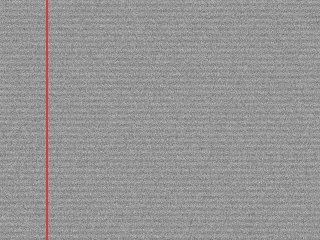

In [10]:
from PIL import Image
import io

fs2 = FrameSource(seed=99)
frame = None
for _ in range(30):
    f = fs2.next_frame()
    if f.label != "no_defect":
        frame = f
        break

if frame:
    img = Image.open(io.BytesIO(frame.image_bytes))
    print(f"Frame {frame.index}, label={frame.label}")
    display(img)
else:
    print("No defect frame hit in 30 draws — re-run this cell (defects are intentionally the minority case)")


## 6. Event-emission decision logic (unit-level demonstration)

Reproduces the exact rule from `edge_simulator/main.py::_maybe_build_events` — new class (with cooldown) and threshold-exceeded — against a short synthetic sequence, so the logic can be inspected without needing the WebSocket/Docker stack running.


In [11]:
import time as _time

ALARM_THRESHOLD = 0.85
NEW_CLASS_COOLDOWN_SECONDS = 120
_seen_classes = {}

def maybe_events(detection_class, confidence, now=None):
    now = now if now is not None else _time.time()
    events = []
    is_new = detection_class != "no_defect" and (
        detection_class not in _seen_classes
        or (now - _seen_classes[detection_class]) > NEW_CLASS_COOLDOWN_SECONDS
    )
    if is_new:
        _seen_classes[detection_class] = now
        events.append("new_anomaly_class")
    if confidence > ALARM_THRESHOLD and detection_class != "no_defect":
        events.append("threshold_exceeded")
    return events

# Simulate: needle_line appears 3 times in a row (persistent defect)
t0 = 1000.0
print("t=0s  ", maybe_events("needle_line", 0.94, now=t0))       # new + alarm
print("t=1s  ", maybe_events("needle_line", 0.90, now=t0 + 1))   # alarm only (cooldown suppresses duplicate "new")
print("t=2s  ", maybe_events("needle_line", 0.60, now=t0 + 2))   # neither (below threshold, still in cooldown)
print("t=130s", maybe_events("needle_line", 0.88, now=t0 + 130)) # new (cooldown expired) + alarm


t=0s   ['new_anomaly_class', 'threshold_exceeded']
t=1s   ['threshold_exceeded']
t=2s   []
t=130s ['new_anomaly_class', 'threshold_exceeded']


This confirms the cooldown behaves as documented in the README: a persistent defect fires the alarm repeatedly (correct — an operator should keep being alerted) but only re-fires the retraining-feeding `new_anomaly_class` event once the cooldown window has passed (correct — it stops flooding the retraining pipeline with near-duplicate frames of the same ongoing defect).


## 7. Telemetry hybrid publisher (disk-first, MQTT-second)

Demonstrates a telemetry point being generated and durably written to disk, independent of whether an MQTT broker is reachable.


In [12]:
from edge_simulator.telemetry import TelemetryGenerator

gen = TelemetryGenerator(device_id="jetson-terrot-de-01-m03", machine_id="M03", seed=11)
for _ in range(3):
    point = gen.next_point()
    print(point)


TelemetryPoint(device_id='jetson-terrot-de-01-m03', machine_id='M03', ts='2026-07-11T00:23:46.596656+00:00', speed_rpm=801.8, yarn_feed_tension=0.9681, jetson_temp_c=52.2, inference_latency_ms=14.52, fps=24.1)
TelemetryPoint(device_id='jetson-terrot-de-01-m03', machine_id='M03', ts='2026-07-11T00:23:46.596927+00:00', speed_rpm=790.5, yarn_feed_tension=0.9716, jetson_temp_c=47.6, inference_latency_ms=16.82, fps=27.5)
TelemetryPoint(device_id='jetson-terrot-de-01-m03', machine_id='M03', ts='2026-07-11T00:23:46.596968+00:00', speed_rpm=794.1, yarn_feed_tension=0.9554, jetson_temp_c=43.0, inference_latency_ms=19.34, fps=26.3)


In [13]:
# Show the local durability buffer (written even if MQTT is unreachable)
buf_path = "edge_simulator/data/telemetry_buffer/buffer.jsonl"
if os.path.exists(buf_path):
    with open(buf_path) as f:
        lines = f.readlines()
    print(f"{len(lines)} telemetry points buffered on disk")
    print("Last 3 lines:")
    for line in lines[-3:]:
        print(" ", line.strip())
else:
    print("No buffer file yet — run the edge-simulator service (docker compose up) to generate one,")
    print("or instantiate HybridTelemetryPublisher directly in this notebook.")


219 telemetry points buffered on disk
Last 3 lines:
  {"device_id": "jetson-terrot-de-01-m03", "machine_id": "M03", "ts": "2026-07-11T00:23:42.069632+00:00", "speed_rpm": 798.6, "yarn_feed_tension": 0.921, "jetson_temp_c": 42.8, "inference_latency_ms": 8.44, "fps": 28.5}
  {"device_id": "jetson-terrot-de-01-m03", "machine_id": "M03", "ts": "2026-07-11T00:23:44.069873+00:00", "speed_rpm": 806.3, "yarn_feed_tension": 0.9027, "jetson_temp_c": 48.3, "inference_latency_ms": 12.33, "fps": 27.5}
  {"device_id": "jetson-terrot-de-01-m03", "machine_id": "M03", "ts": "2026-07-11T00:23:46.070717+00:00", "speed_rpm": 789.1, "yarn_feed_tension": 0.8834, "jetson_temp_c": 47.0, "inference_latency_ms": 8.35, "fps": 28.0}


---
## 8. Summary

| Requirement | Demonstrated in |
|---|---|
| Queue/consumer service, two event types | Sections 2–3 |
| Persistence layer | Section 3 (`/events/recent`, backed by Postgres) |
| Metrics: total processed, backlog, distribution by type | Section 3 |
| Extra metrics (rate, staleness, per-class/factory) | Section 3 |
| Consumer reliability (no data loss on failure) | Sections 3.4, 4 |
| Local disk vs MQTT decision, implemented | Section 7, `docs/DESIGN_NOTES.md` §1 |
| Mocked anomaly detection | Section 5 |
| Event-emission rules incl. justified deviation (cooldown) | Section 6, README §4.3 |
| Live camera feed + alerts + cloud health panel | `edge_simulator/static/index.html` (open http://localhost:8002 while `docker compose up` is running) |

See `README.md` for the full architecture writeup and `docs/DESIGN_NOTES.md` for the production-readiness discussion.
